In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
df = pd.read_csv('titanic.csv') 
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print("Shape:",df.shape) 
print("\nColumns:",df.columns.tolist()) 
print("\nMissing Values:\n",df.isnull().sum()) 
print("\nBasic Stats:\n",df.describe()) 

Shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Basic Stats:
        PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    

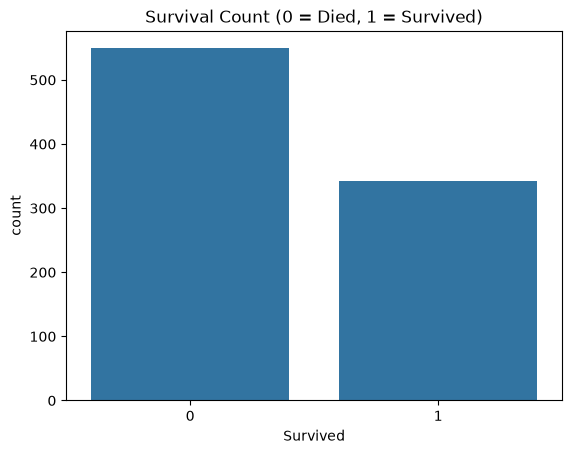

In [3]:
sns.countplot(x ='Survived', data = df) 
plt.title('Survival Count (0 = Died, 1 = Survived)') 
plt.show() 

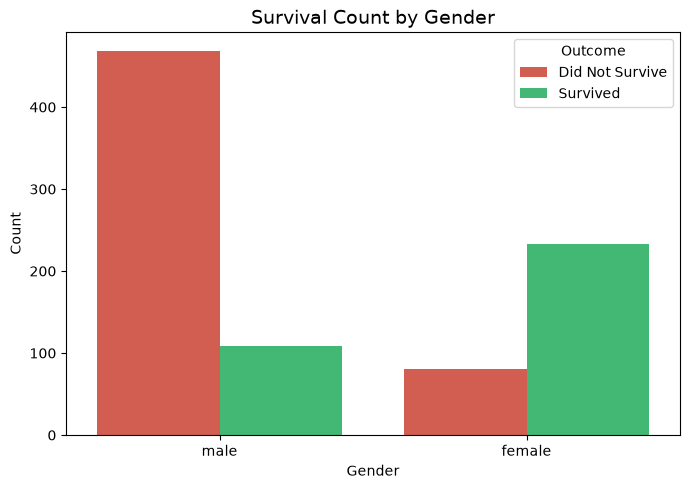


--- Survival Rate by Gender ---
Sex
female    74.2%
male      18.9%
Name: Survived, dtype: str


In [4]:
plt.figure(figsize =(7,5)) 
sns.countplot(data = df, x = 'Sex', hue ='Survived',palette ={0:'#e74c3c',1:'#2ecc71'}) 

plt.title('Survival Count by Gender', fontsize = 14) 
plt.xlabel('Gender') 
plt.ylabel('Count') 
plt.legend(labels =['Did Not Survive','Survived'], title ='Outcome') 
plt.tight_layout() 
plt.show() 

print("\n--- Survival Rate by Gender ---") 
print(df.groupby('Sex')['Survived'].mean().apply(lambda x: f"{x:.1%}")) 


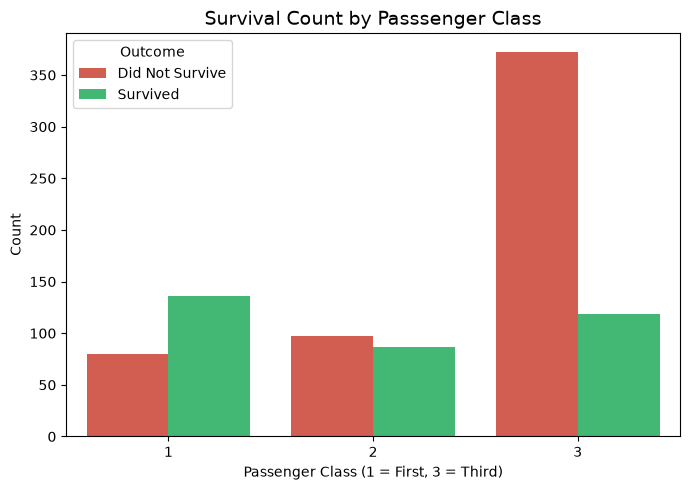


--- Survival Rate by Class ---
Pclass
1    63.0%
2    47.3%
3    24.2%
Name: Survived, dtype: str


In [5]:
plt.figure(figsize =(7,5)) 
sns.countplot(data = df, x ='Pclass', hue = 'Survived', palette ={0:'#e74c3c',1:'#2ecc71'}) 

plt.title('Survival Count by Passsenger Class', fontsize =14) 
plt.xlabel('Passenger Class (1 = First, 3 = Third)') 
plt.ylabel('Count') 
plt.legend(labels =['Did Not Survive', 'Survived'],title ='Outcome') 
plt.tight_layout() 
plt.show() 

print("\n--- Survival Rate by Class ---") 
print(df.groupby('Pclass')['Survived'].mean().apply(lambda x: f"{x:.1%}")) 

Task was destroyed but it is pending!
task: <Task pending name='Task-65' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Vidit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-66' coro=<Kernel.shell_main() running at C:\Users\Vidit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Vidit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\Vidit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\transforms.py:193: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  ref = weakref.ref(
Task was destroyed but it is pending!
task: <Task pending name='Task-66' coro=<Kernel.shell_main() running at C:\Users\Vidit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ipykernel\kernelbase.py:597> cb=

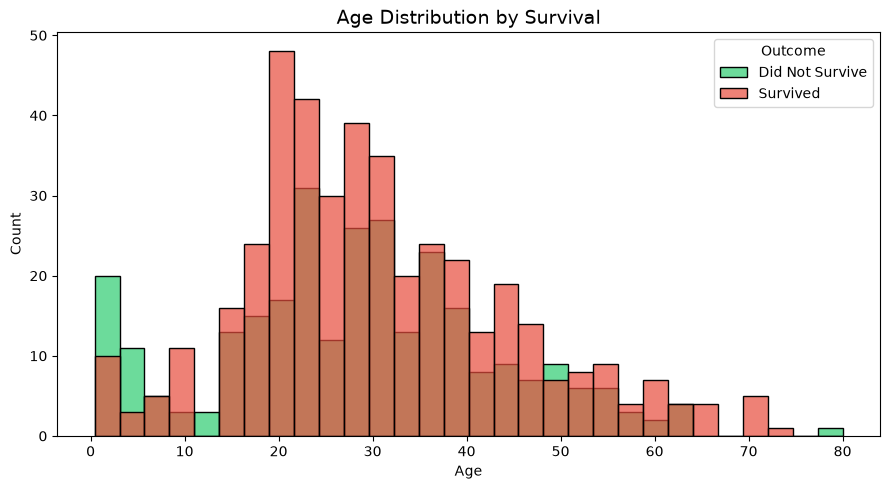


Age Stats:
Mean Age: 29.7years
Missing Age values:177


In [6]:
#Cell 6: Age Distribution 
plt.figure(figsize =(9,5)) 
sns.histplot(data = df, x = 'Age', hue = 'Survived', bins = 30, 
             palette = {0:'#e74c3c', 1:'#2ecc71'}, alpha = 0.7) 

plt.title('Age Distribution by Survival', fontsize = 14) 
plt.xlabel('Age') 
plt.ylabel('Count') 
plt.legend(labels = ['Did Not Survive', 'Survived'], title = 'Outcome') 
plt.tight_layout() 
plt.show() 

print(f"\nAge Stats:") 
print(f"Mean Age: {df['Age'].mean():.1f}years") 
print(f"Missing Age values:{df['Age'].isnull().sum()}") 

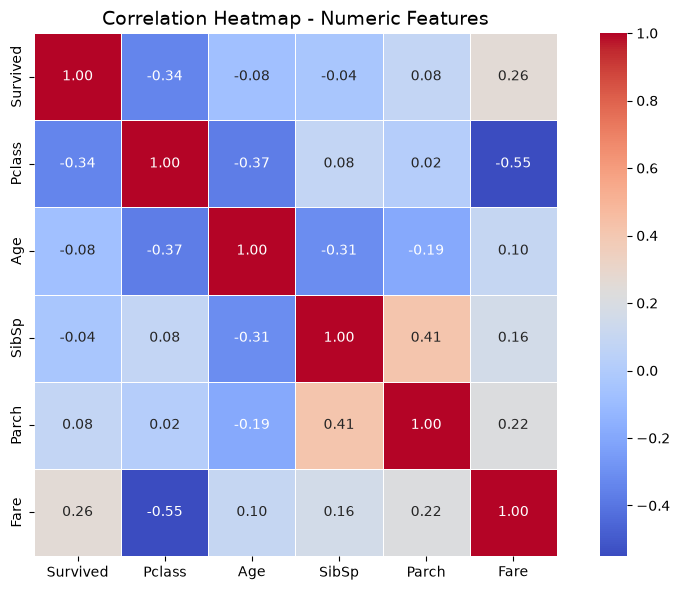

In [7]:
# cell 7: Correlation Heatmap 
plt.figure(figsize = (9,6)) 
numeric_df = df[['Survived', 'Pclass', 'Age','SibSp', 'Parch', 'Fare']] 
sns.heatmap(numeric_df.corr(), annot = True, fmt = '.2f', 
            cmap = 'coolwarm', linewidths = 0.5, square = True) 

plt.title('Correlation Heatmap - Numeric Features', fontsize = 14) 
plt.tight_layout() 
plt.show() 